In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from experiments.plotting import _plot_SRE_distribution, view_correlation

from src.utils import configure_logger
from GNN.training.utils import to_scalar
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [4]:
model_type="gnn"
epochs = 40
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"


model_hparams = {
    "gnn_hidden": 128,
    "gnn_heads": 8,
    "global_hidden": 128,
    "reg_hidden": 64,
    "num_layers": 3,
    "dropout_rate": 0.14466592901950354,
}

train_hparams = {
    "weight_decay": 0.0011100615729802686,
    "grad_clip": 18.68332578469687,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

In [5]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-06-19 08:33:30,164 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-19 08:33:30,168 - GNN.training.runners - INFO - Training configuration done.
2026-06-19 08:33:30,168 - GNN.training.runners - INFO - Collecting data paths...
2026-06-19 08:33:30,170 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-19 08:33:30,171 - GNN.training.runners - INFO - Data paths collected.
2026-06-19 08:33:30,171 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-19 08:35:12,708 - GNN.training.runners - INFO - Loaders and model built.
2026-06-19 08:35:12,710 - GNN.training.runners - INFO - Starting training...
2026-06-19 08:35:12,710 - GNN.training.train - INFO - Using device: cuda
2026-06-19 08:35:12,906 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/40:  45%|████▌     | 91/201 [01:00<01:11,  1.54it/s, loss=0.0368, graphs=11776]

2026-06-19 08:36:13,083 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 92/201 | loss 0.036773 | elapsed 60.2s | graphs 11776


Epoch 1/40:  94%|█████████▎| 188/201 [02:00<00:08,  1.61it/s, loss=0.0353, graphs=24192]

2026-06-19 08:37:13,267 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 189/201 | loss 0.035344 | elapsed 120.4s | graphs 24192


...

2026-06-19 09:14:29,756 - GNN.training.train - INFO - Losses | train 0.032475 | val 0.033958 | lr 2.47e-04 | time train=129.4s val=14.4s total=143.8s
2026-06-19 09:14:29,757 - GNN.training.train - INFO - -------- EPOCH 018 --------


Epoch 18/40:  49%|████▉     | 98/201 [01:00<00:55,  1.87it/s, loss=0.0321, graphs=12672]

2026-06-19 09:15:30,291 - GNN.training.train - INFO - [Heartbeat] Epoch 18 batch 99/201 | loss 0.032134 | elapsed 60.5s | graphs 12672


2026-06-19 09:16:26,799 - GNN.training.train - INFO - Training complete (117.0s) | running validation...


2026-06-19 09:16:38,996 - GNN.training.train - INFO - Losses | train 0.032429 | val 0.033953 | lr 2.47e-04 | time train=117.0s val=12.2s total=129.2s
2026-06-19 09:16:38,996 - GNN.training.train - INFO - Early stopping at epoch 018 | best val 0.033901 | patience exhausted (15/15)
2026-06-19 09:19:45,378 - GNN.training.runners - INFO - Training complete.
2026-06-19 09:19:45,504 - experiments.plotting - INFO - Saved training curve plot to outputs\figures\training_curves\training_curves_gnn_huber_random_3.png
2026-06-19 09:19:45,515 - GNN.training.runners - INFO - Saved model checkpoint to ..\notebooks\outputs\models\final\random_model_gnn_per_family_sre_density.pt
2026-06-19 09:19:45,564 - scripts.train_model - INFO - Final test loss: 0.031970
2026-06-19 09:19:45,566 - scripts.train_model - INFO - Test R2 score: -0.0081
2026-06-19 09:19:45,567 - scripts.train_model - INFO - Validation R2 score: -0.0105
2026-06-19 09:19:45,567 - scripts.train_model - INFO - Training R2 score: -0.0076


In [6]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = f"../notebooks/outputs/models/final/random_model_gnn_per_family_sre_density.pt"
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-19 09:40:07,396 - scripts.predictions - INFO - Loading checkpoint: ../notebooks/outputs/models/final/random_model_gnn_per_family_sre_density.pt
2026-06-19 09:40:07,405 - scripts.predictions - INFO - Found 1 prediction files
Predicting (gnn): 100%|██████████| 7810/7810 [13:51<00:00,  9.39batch/s]
2026-06-19 09:54:36,177 - scripts.predictions - INFO - Saved 124950 predictions to outputs/predictions/family/gnn_predictions_random.csv


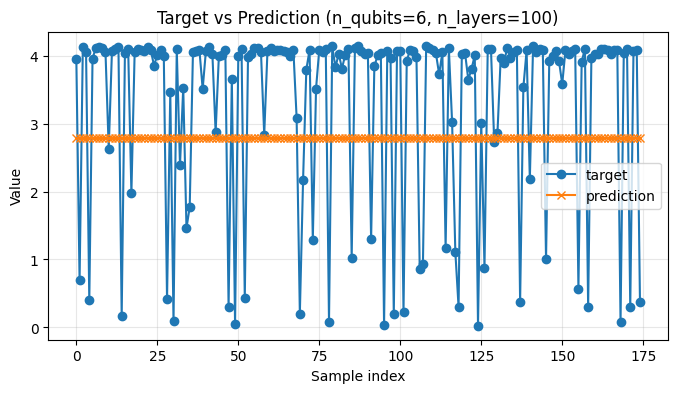

Pearson r = 0.0345


Text(0.5, 1.0, 'True vs Predicted SRE for Quansistor Family (GNN Model)')

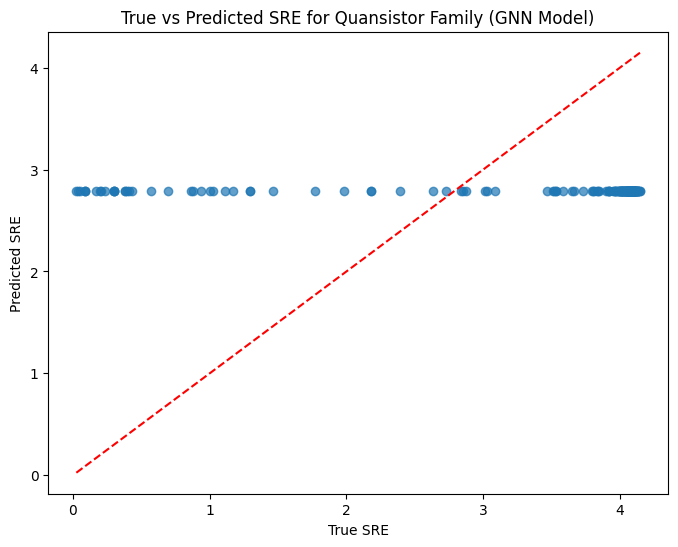

In [10]:
df = pd.read_csv(f"outputs/predictions/family/gnn_predictions_random.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

nq=plot_qubits
nl=plot_layers

view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target_SRE",
    col_y="predicted_SRE",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target_SRE"], df["predicted_SRE"], alpha=0.7)
plt.plot([df["target_SRE"].min(), df["target_SRE"].max()], [df["target_SRE"].min(), df["target_SRE"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Quansistor Family (GNN Model)")

### Optuna search

In [ ]:
study_name = f"optuna_search_{model_type}_{training_mode}_{family}_{target}_1"
storage_url = "sqlite:///optuna_studies.db"
n_trials = 15

optuna_search(
    model_type=model_type,
    training_mode=training_mode,
    family=family,
    data_dir=training_data_dir,
    target=target,
    study_name=study_name,
    storage_url=storage_url,
    n_trials=n_trials,
)

2026-06-15 20:01:43,708 - scripts.optuna_search - INFO - Starting Optuna hyperparameter search...
2026-06-15 20:01:43,718 - scripts.optuna_search - INFO - Found 1 dataset files for target=sre in data_dir=../outputs/data/datasets_SRE.
2026-06-15 20:03:12,513 - scripts.optuna_search - INFO - Prepared datasets with loader_kind=gnn. Starting Optuna study with name='optuna_search_gnn_per_family_random_sre_1' and storage='sqlite:///optuna_studies.db'...
[I 2026-06-15 20:03:12,608] A new study created in RDB with name: optuna_search_gnn_per_family_random_sre_1
2026-06-15 20:03:12,612 - scripts.optuna_search - INFO - Running Optuna optimization for 15 trials...
2026-06-15 20:03:12,745 - GNN.training.train - INFO - Using device: cuda
2026-06-15 20:03:19,287 - GNN.training.train - INFO - -------- EPOCH 001 --------
2026-06-15 20:04:19,517 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 98/201 | loss 0.221011 | elapsed 60.2s | graphs 12544
2026-06-15 20:05:19,663 - GNN.training.train - IN